In [1]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float32,
)
pipe = pipe.to("mps")
pipe.enable_attention_slicing()  # recommended on MPS to avoid memory spikes
print("Stable Diffusion 1.4 loaded:", type(pipe).__name__, "on", pipe.device)

/opt/anaconda3/envs/diffusion231/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 16.34it/s]


Stable Diffusion 1.4 loaded: StableDiffusionPipeline on mps:0


In [ ]:
# Test generation
prompt = "a photo of an astronaut riding a horse"
generator = torch.Generator(device="cpu").manual_seed(42)  # CPU generator -> reproducible on MPS

image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator,
).images[0]

image.save("test2_output.png")
print("saved test2_output.png", image.size)
image

In [4]:
# Test generation
prompt = "cat in van gogh style"
generator = torch.Generator(device="cpu").manual_seed(42)  # CPU generator -> reproducible on MPS

image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator,
).images[0]

image.save("test2_output.png")
print("saved test2_output.png", image.size)

100%|██████████| 30/30 [00:25<00:00,  1.19it/s]


saved test2_output.png (512, 512)


In [5]:
import torch

# Param counts per component
for name in ["unet", "vae", "text_encoder"]:
    m = getattr(pipe, name)
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:13s} {type(m).__name__:28s} {n/1e6:8.1f}M params")

print("\n--- first 8 UNet parameters (name, shape) ---")
for i, (pname, p) in enumerate(pipe.unet.named_parameters()):
    if i >= 8: break
    print(f"{pname:45s} {tuple(p.shape)}  dtype={p.dtype}")

print("\n--- one actual weight tensor (conv_in.weight) ---")
w = pipe.unet.state_dict()["conv_in.weight"]
print("shape:", tuple(w.shape))
print(w.flatten()[:6], "...")

unet          UNet2DConditionModel            859.5M params
vae           AutoencoderKL                    83.7M params
text_encoder  CLIPTextModel                   123.1M params

--- first 8 UNet parameters (name, shape) ---
conv_in.weight                                (320, 4, 3, 3)  dtype=torch.float32
conv_in.bias                                  (320,)  dtype=torch.float32
time_embedding.linear_1.weight                (1280, 320)  dtype=torch.float32
time_embedding.linear_1.bias                  (1280,)  dtype=torch.float32
time_embedding.linear_2.weight                (1280, 1280)  dtype=torch.float32
time_embedding.linear_2.bias                  (1280,)  dtype=torch.float32
down_blocks.0.attentions.0.norm.weight        (320,)  dtype=torch.float32
down_blocks.0.attentions.0.norm.bias          (320,)  dtype=torch.float32

--- one actual weight tensor (conv_in.weight) ---
shape: (320, 4, 3, 3)
tensor([-0.0316,  0.0874,  0.0948, -0.0331, -0.2252,  0.1446], device='mps:0') ...


In [8]:
pipe.unet 

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [ ]:
# ============================================================
# Manual Stable Diffusion denoising — ONE timestep, with shapes
# ============================================================
import torch

device = pipe.device
prompt = "a photo of an astronaut riding a horse"
height = width = 512
num_inference_steps = 30
guidance_scale = 7.5

def show(name, t):
    print(f"{name:34s} {tuple(t.shape)}")

# --- 1. Text -> embeddings (conditional + unconditional, for classifier-free guidance) ---
tok = pipe.tokenizer(prompt, padding="max_length",
                     max_length=pipe.tokenizer.model_max_length,
                     truncation=True, return_tensors="pt")
show("input_ids (tokenized prompt)", tok.input_ids)
with torch.no_grad():
    cond = pipe.text_encoder(tok.input_ids.to(device))[0]
show("conditional text embeddings", cond)

uncond_tok = pipe.tokenizer([""], padding="max_length",
                            max_length=pipe.tokenizer.model_max_length,
                            return_tensors="pt")
with torch.no_grad():
    uncond = pipe.text_encoder(uncond_tok.input_ids.to(device))[0]
show("unconditional text embeddings", uncond)

text_embeddings = torch.cat([uncond, cond])      # stack uncond+cond into one batch
show("text_embeddings (concatenated)", text_embeddings)

# --- 2. Initial latent noise (this is what we denoise, NOT pixels) ---
generator = torch.Generator(device="cpu").manual_seed(42)
latents = torch.randn((1, pipe.unet.config.in_channels, height // 8, width // 8),
                      generator=generator).to(device)
show("initial latents (random noise)", latents)

# --- 3. Scheduler setup ---
pipe.scheduler.set_timesteps(num_inference_steps)
latents = latents * pipe.scheduler.init_noise_sigma
t = pipe.scheduler.timesteps[0]
print(f"\nfirst timestep t = {int(t)}   (scheduler = {type(pipe.scheduler).__name__})\n")

# --- 4. ONE denoising step ---
latent_model_input = torch.cat([latents] * 2)    # duplicate: one copy for uncond, one for cond
show("latent_model_input (x2 batch)", latent_model_input)
latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
show("after scale_model_input", latent_model_input)

with torch.no_grad():
    noise_pred = pipe.unet(latent_model_input, t,
                           encoder_hidden_states=text_embeddings).sample
show("noise_pred (UNet output)", noise_pred)

noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
show("  -> noise_pred_uncond", noise_pred_uncond)
show("  -> noise_pred_text", noise_pred_text)

# classifier-free guidance: push away from uncond, toward the prompt
noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
show("noise_pred (after guidance)", noise_pred)

latents_after = pipe.scheduler.step(noise_pred, t, latents).prev_sample
show("latents after 1 step", latents_after)

In [9]:
# ============================================================
# Manual Stable Diffusion denoising — ONE timestep, with shapes
# ============================================================
import torch

device = pipe.device
prompt = "a photo of an astronaut riding a horse"
height = width = 512
num_inference_steps = 30
guidance_scale = 7.5

def show(name, t):
    print(f"{name:34s} {tuple(t.shape)}")

# --- 1. Text -> embeddings (conditional + unconditional, for classifier-free guidance) ---
tok = pipe.tokenizer(prompt, padding="max_length",
                     max_length=pipe.tokenizer.model_max_length,
                     truncation=True, return_tensors="pt")
show("input_ids (tokenized prompt)", tok.input_ids)
with torch.no_grad():
    cond = pipe.text_encoder(tok.input_ids.to(device))[0]
show("conditional text embeddings", cond)

uncond_tok = pipe.tokenizer([""], padding="max_length",
                            max_length=pipe.tokenizer.model_max_length,
                            return_tensors="pt")
with torch.no_grad():
    uncond = pipe.text_encoder(uncond_tok.input_ids.to(device))[0]
show("unconditional text embeddings", uncond)

text_embeddings = torch.cat([uncond, cond])      # stack uncond+cond into one batch
show("text_embeddings (concatenated)", text_embeddings)

# --- 2. Initial latent noise (this is what we denoise, NOT pixels) ---
generator = torch.Generator(device="cpu").manual_seed(42)
latents = torch.randn((1, pipe.unet.config.in_channels, height // 8, width // 8),
                      generator=generator).to(device)
show("initial latents (random noise)", latents)

# --- 3. Scheduler setup ---
pipe.scheduler.set_timesteps(num_inference_steps)
latents = latents * pipe.scheduler.init_noise_sigma
t = pipe.scheduler.timesteps[0]
print(f"\nfirst timestep t = {int(t)}   (scheduler = {type(pipe.scheduler).__name__})\n")

# --- 4. ONE denoising step ---
latent_model_input = torch.cat([latents] * 2)    # duplicate: one copy for uncond, one for cond
show("latent_model_input (x2 batch)", latent_model_input)
latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
show("after scale_model_input", latent_model_input)

with torch.no_grad():
    noise_pred = pipe.unet(latent_model_input, t,
                           encoder_hidden_states=text_embeddings).sample
show("noise_pred (UNet output)", noise_pred)

noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
show("  -> noise_pred_uncond", noise_pred_uncond)
show("  -> noise_pred_text", noise_pred_text)

# classifier-free guidance: push away from uncond, toward the prompt
noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
show("noise_pred (after guidance)", noise_pred)

latents_after = pipe.scheduler.step(noise_pred, t, latents).prev_sample
show("latents after 1 step", latents_after)

input_ids (tokenized prompt)       (1, 77)
conditional text embeddings        (1, 77, 768)
unconditional text embeddings      (1, 77, 768)
text_embeddings (concatenated)     (2, 77, 768)
initial latents (random noise)     (1, 4, 64, 64)

first timestep t = 958   (scheduler = PNDMScheduler)

latent_model_input (x2 batch)      (2, 4, 64, 64)
after scale_model_input            (2, 4, 64, 64)
noise_pred (UNet output)           (2, 4, 64, 64)
  -> noise_pred_uncond             (1, 4, 64, 64)
  -> noise_pred_text               (1, 4, 64, 64)
noise_pred (after guidance)        (1, 4, 64, 64)
latents after 1 step               (1, 4, 64, 64)


captured 32 frames (start + 30 steps)


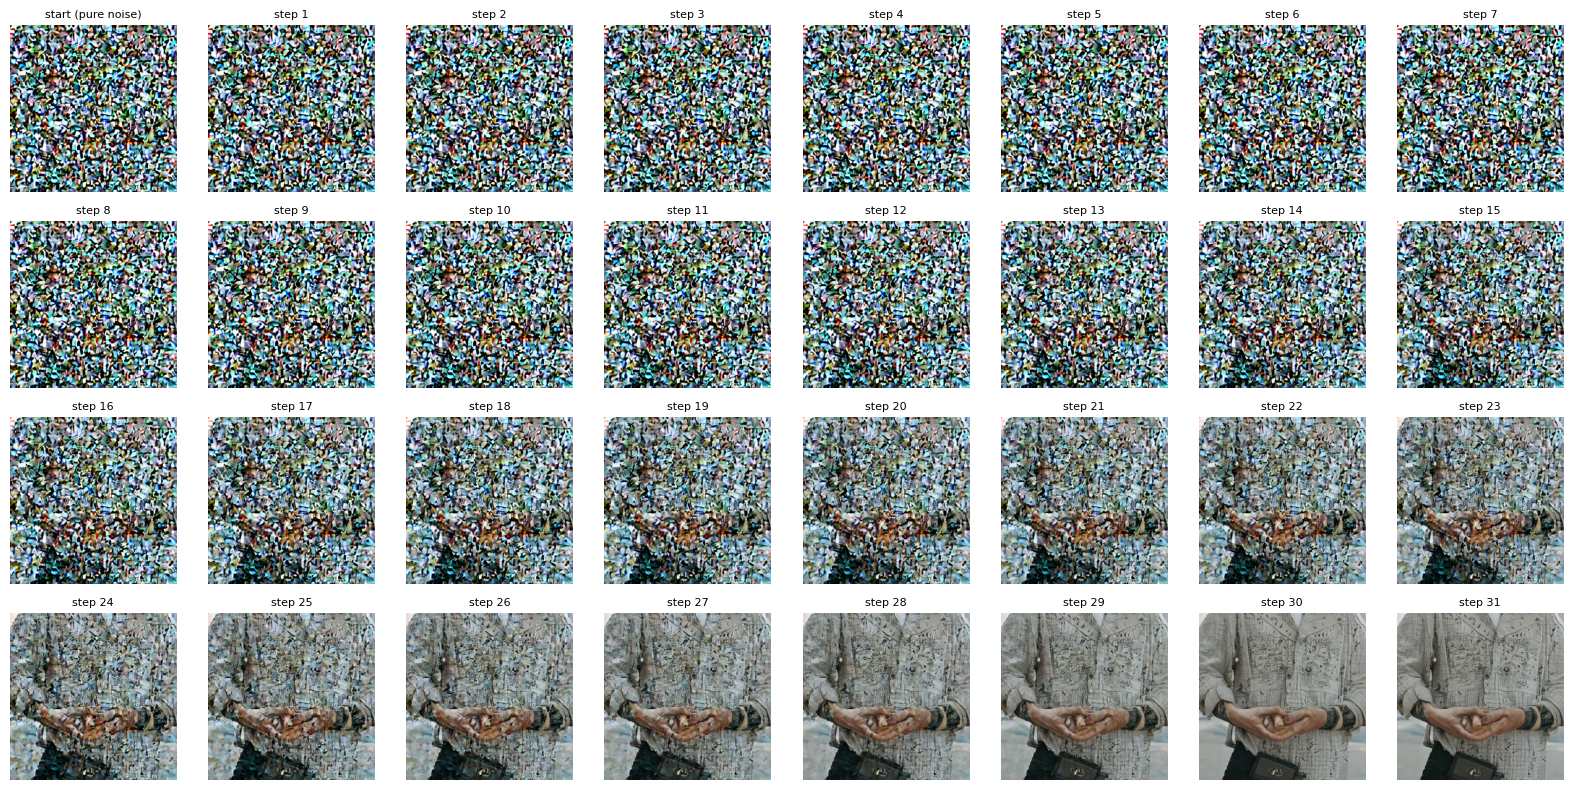

saved denoising_trajectory.png


In [12]:
# ============================================================
# Full 30-step denoising loop ("just like the pipeline does")
# + visualize the start and every denoising step
# ============================================================
import torch, math
import matplotlib.pyplot as plt
from PIL import Image

device = pipe.device
prompt = "dog getting walked in van gogh style"
height = width = 512
num_inference_steps = 30
guidance_scale = 0 

# --- text embeddings (uncond + cond) ---
def embed(text):
    tk = pipe.tokenizer(text, padding="max_length",
                        max_length=pipe.tokenizer.model_max_length,
                        truncation=True, return_tensors="pt")
    with torch.no_grad():
        return pipe.text_encoder(tk.input_ids.to(device))[0]
text_embeddings = torch.cat([embed([""]), embed(prompt)])

# --- initial latents + scheduler ---
generator = torch.Generator(device="cpu").manual_seed(42)
latents = torch.randn((1, pipe.unet.config.in_channels, height // 8, width // 8),
                      generator=generator).to(device)
pipe.scheduler.set_timesteps(num_inference_steps)
latents = latents * pipe.scheduler.init_noise_sigma

# --- helper: decode a latent to a PIL image via the VAE ---
@torch.no_grad()
def decode(lat):
    img = pipe.vae.decode(lat / pipe.vae.config.scaling_factor).sample
    img = (img / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).float().numpy()
    return Image.fromarray((img * 255).round().astype("uint8"))

frames = [("start (pure noise)", decode(latents))]      # the starting point

# --- denoising loop ---
for i, t in enumerate(pipe.scheduler.timesteps):
    latent_model_input = pipe.scheduler.scale_model_input(torch.cat([latents] * 2), t)
    with torch.no_grad():
        noise_pred = pipe.unet(latent_model_input, t,
                               encoder_hidden_states=text_embeddings).sample
    nu, nt = noise_pred.chunk(2)
    noise_pred = nu + guidance_scale * (nt - nu)          # classifier-free guidance
    latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
    frames.append((f"step {i+1}", decode(latents)))       # decode current latent

print(f"captured {len(frames)} frames (start + {num_inference_steps} steps)")

# --- visualize as a grid ---
cols = 8
rows = math.ceil(len(frames) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
for ax in axes.flat:
    ax.axis("off")
for ax, (title, im) in zip(axes.flat, frames):
    ax.imshow(im)
    ax.set_title(title, fontsize=8)
plt.tight_layout()
plt.savefig("denoising_trajectory.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved denoising_trajectory.png")